<a href="https://colab.research.google.com/github/lsliskov/emotion-recognition-distilbert/blob/main/Emotion_Recognition_DistilBERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##DATASET

In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("dair-ai/emotion", "split")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [ ]:
print("Train:", len(dataset["train"]))
print("Validation:", len(dataset["validation"]))
print("Test:", len(dataset["test"]))

Train: 16000
Validation: 2000
Test: 2000


In [ ]:
label_names = dataset["train"].features["label"].names

print(label_names)

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [ ]:
dataset["train"][0]

{'text': 'i didnt feel humiliated', 'label': 0}

In [ ]:
for label_id, label_name in enumerate(label_names):
    example = next(
        item for item in dataset["train"]
        if item["label"] == label_id
    )

    print(f"{label_name.upper()}:")
    print(example["text"])
    print()

SADNESS:
i didnt feel humiliated

JOY:
i have been with petronas for years i feel that petronas has performed well and made a huge profit

LOVE:
i am ever feeling nostalgic about the fireplace i will know that it is still on the property

ANGER:
im grabbing a minute to post i feel greedy wrong

FEAR:
i feel as confused about life as a teenager or as jaded as a year old man

SURPRISE:
ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny



In [ ]:
for i in range(10):
    text = dataset["train"][i]["text"]
    label = dataset["train"][i]["label"]

    print("Tekst:", text)
    print("Emocija:", label_names[label])
    print()

Tekst: i didnt feel humiliated
Emocija: sadness

Tekst: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Emocija: sadness

Tekst: im grabbing a minute to post i feel greedy wrong
Emocija: anger

Tekst: i am ever feeling nostalgic about the fireplace i will know that it is still on the property
Emocija: love

Tekst: i am feeling grouchy
Emocija: anger

Tekst: ive been feeling a little burdened lately wasnt sure why that was
Emocija: sadness

Tekst: ive been taking or milligrams or times recommended amount and ive fallen asleep a lot faster but i also feel like so funny
Emocija: surprise

Tekst: i feel as confused about life as a teenager or as jaded as a year old man
Emocija: fear

Tekst: i have been with petronas for years i feel that petronas has performed well and made a huge profit
Emocija: joy

Tekst: i feel romantic too
Emocija: love



##EXPLORATORY DATA ANALYSIS

In [ ]:
import pandas as pd

train_df = dataset["train"].to_pandas()

train_df["emotion"] = train_df["label"].apply(lambda x: label_names[x])

label_counts = train_df["emotion"].value_counts()

print(label_counts)

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64


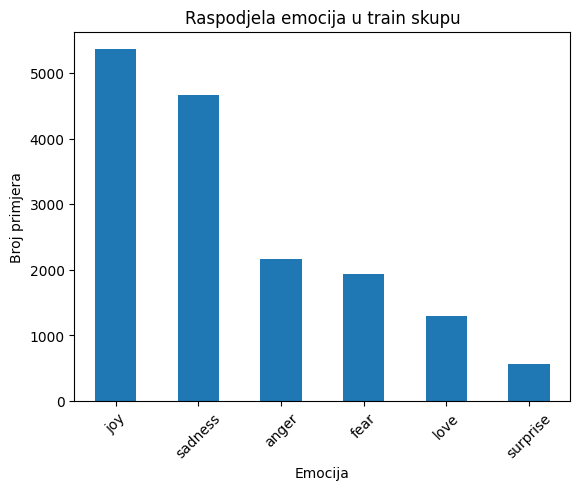

In [ ]:
import matplotlib.pyplot as plt

label_counts.plot(kind="bar")

plt.title("Raspodjela emocija u train skupu")
plt.xlabel("Emocija")
plt.ylabel("Broj primjera")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Broj riječi u svakom tekstu
train_df["word_count"] = train_df["text"].apply(lambda x: len(x.split()))

print(train_df["word_count"].describe())

count    16000.000000
mean        19.166313
std         10.986905
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: word_count, dtype: float64


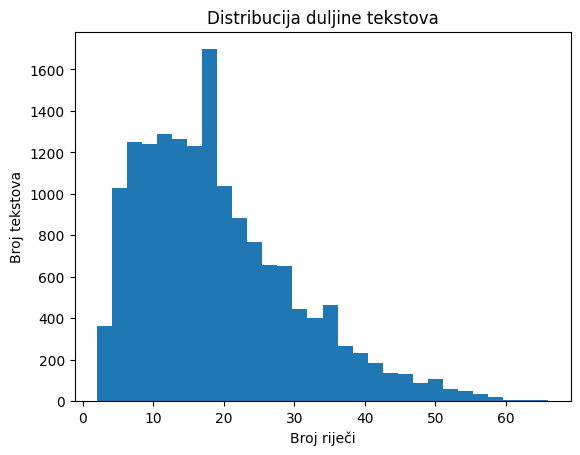

In [ ]:
plt.hist(train_df["word_count"], bins=30)

plt.title("Distribucija duljine tekstova")
plt.xlabel("Broj riječi")
plt.ylabel("Broj tekstova")
plt.show()

In [ ]:
length_by_emotion = train_df.groupby("emotion")["word_count"].agg(
    ["count", "mean", "median", "min", "max"]
)

length_by_emotion

,count,mean,median,min,max
emotion,,,,,
anger,2159,19.229736,17.0,2,62
fear,1937,18.844605,17.0,2,60
joy,5362,19.498135,18.0,2,64
love,1304,20.700153,19.0,3,63
sadness,4666,18.361980,16.0,2,66
surprise,572,19.970280,18.0,3,60


In [ ]:
import re

def has_punctuation(text):
    return bool(re.search(r"[^\w\s]", text))

def has_uppercase(text):
    return any(c.isupper() for c in text)

def has_digit(text):
    return any(c.isdigit() for c in text)

def has_repeated_letters(text):
    # npr. sooo, happyyy, noooo
    return bool(re.search(r"([a-zA-Z])\1{2,}", text))

def has_emoji(text):
    # približna provjera najčešćih Unicode emoji područja
    return bool(re.search(
        r"[\U0001F300-\U0001FAFF\U00002600-\U000027BF]",
        text
    ))

checks = {
    "Interpunkcija": train_df["text"].apply(has_punctuation).sum(),
    "Velika slova": train_df["text"].apply(has_uppercase).sum(),
    "Brojke": train_df["text"].apply(has_digit).sum(),
    "Ponavljanje slova": train_df["text"].apply(has_repeated_letters).sum(),
    "Emoji": train_df["text"].apply(has_emoji).sum()
}

for name, count in checks.items():
    print(f"{name}: {count} ({count / len(train_df) * 100:.2f}%)")

Interpunkcija: 0 (0.00%)
Velika slova: 0 (0.00%)
Brojke: 0 (0.00%)
Ponavljanje slova: 127 (0.79%)
Emoji: 0 (0.00%)


In [ ]:
repeated_examples = train_df[
    train_df["text"].apply(has_repeated_letters)
]["text"]

for text in repeated_examples.head(20):
    print(text)

i shalt say we did cos i din feel a thing when he wrote hw he is keen on xxx
i am so festive this feels so delicious wheeeeee what a great night
i am happpy when i get good results in the field of academics or athletics
i knew it was the holy spirit at work plus it feels divine in the gooooood way like a massage reassuring me
i was feeling really horny all afternoon with no one to fulfill ma sexual desire and only had my bed and creative thoughts to help me out and not forgetting my handss which aahhh work like magic
i feel so carefree nowwwwww
i feel unwelcome at work sometimes and think people might be talking about me rel bookmark i feel unwelcome at work sometimes and think people might be talking about me april a class url fn n href http www
i really feel that we are progressing towards a society that is more fearless incrementally throwing away seemingly rigid boundaries like paranoia over security of one s belongings a href http www
i feel fearless janelle mon e elle canada febr

In [ ]:
for split in ["train", "validation", "test"]:
    df = dataset[split].to_pandas()

    repeated_count = df["text"].apply(has_repeated_letters).sum()
    percentage = repeated_count / len(df) * 100

    print(
        f"{split}: {repeated_count} / {len(df)} "
        f"({percentage:.2f}%)"
    )

train: 127 / 16000 (0.79%)
validation: 17 / 2000 (0.85%)
test: 14 / 2000 (0.70%)


##TOKENIZACIJA I PRIPREMA PODATAKA


In [ ]:
!pip install -q transformers

In [ ]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased" #dataset ima samo mala slova
tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
text = dataset["train"][0]["text"]

print("Original:")
print(text)

tokens = tokenizer.tokenize(text)

print("\nTokeni:")
print(tokens)

print("\nBroj riječi:", len(text.split()))
print("Broj tokena:", len(tokens))

Original:
i didnt feel humiliated

Tokeni:
['i', 'didn', '##t', 'feel', 'humiliated']

Broj riječi: 4
Broj tokena: 5


In [ ]:
examples = [
    "happy",
    "hapy",
    "happpy",
    "so",
    "soooo",
    "good",
    "gooood",
    "gooooood"
]

for word in examples:
    print(f"{word:10} -> {tokenizer.tokenize(word)}")

happy      -> ['happy']
hapy       -> ['ha', '##py']
happpy     -> ['ha', '##pp', '##py']
so         -> ['so']
soooo      -> ['soo', '##oo']
good       -> ['good']
gooood     -> ['goo', '##ood']
gooooood   -> ['goo', '##oo', '##ood']


In [ ]:
train_df["token_count"] = train_df["text"].apply(
    lambda text: len(tokenizer.tokenize(text))
)

print(train_df["token_count"].describe())

count    16000.000000
mean        20.259500
std         11.575801
min          2.000000
25%         11.000000
50%         18.000000
75%         27.000000
max         85.000000
Name: token_count, dtype: float64


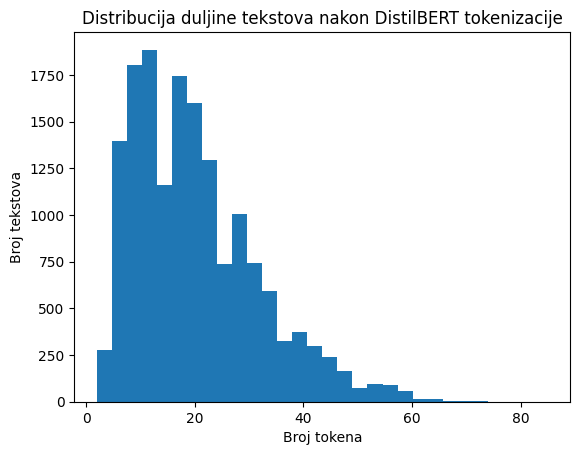

In [ ]:
plt.hist(train_df["token_count"], bins=30)

plt.title("Distribucija duljine tekstova nakon DistilBERT tokenizacije")
plt.xlabel("Broj tokena")
plt.ylabel("Broj tekstova")

plt.show()

In [ ]:
train_df.sort_values("token_count", ascending=False)[
    ["text", "emotion", "word_count", "token_count"]
].head(10)

,text,emotion,word_count,token_count
9753,i just feel you so so dont be afraid naega deo...,fear,49,85
14644,i feel lethargic and getting pressure between ...,sadness,29,76
7222,i am happier this year in all ways i am just g...,joy,64,73
9618,i feel you i dont believ in you but i keep my ...,joy,64,73
6322,i guess which meant or so i assume no photos n...,sadness,66,70
2881,i like to notify that i all the time feel my s...,love,55,70
1542,i feel tat all of us in this world are clever ...,joy,62,69
287,i said in the words of a devotee that i feel r...,joy,61,68
6995,i have decided that i want to go to school for...,joy,60,67
9626,i feel in my bones like nobody cares if im her...,sadness,64,67


In [ ]:
for max_len in [32, 64, 96, 128]:
    count = (train_df["token_count"] + 2 > max_len).sum()
    percentage = count / len(train_df) * 100

    print(
        f"max_length={max_len}: "
        f"{count} tekstova bi bilo skraćeno ({percentage:.2f}%)"
    )

max_length=32: 2847 tekstova bi bilo skraćeno (17.79%)
max_length=64: 25 tekstova bi bilo skraćeno (0.16%)
max_length=96: 0 tekstova bi bilo skraćeno (0.00%)
max_length=128: 0 tekstova bi bilo skraćeno (0.00%)


In [ ]:
MAX_LENGTH = 96

## MODEL A - FULL FINE-TUNING DISTILBERT-A

In [ ]:
import torch

print("CUDA dostupna:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA dostupna: True
GPU: Tesla T4


In [ ]:
!pip install -q transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 96

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [ ]:
def tokenize_function(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH
    )

In [ ]:
tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [ ]:
id2label = {i: label for i, label in enumerate(label_names)}
label2id = {label: i for i, label in enumerate(label_names)}

print(id2label)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [ ]:
from transformers import AutoModelForSequenceClassification

model_a = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

def compute_metrics(eval_pred):
    predictions, labels = eval_pred

    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    macro_f1 = f1_score(labels, predictions, average="macro")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1
    }

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from transformers import TrainingArguments

training_args_a = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_project/model_a_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer_a = Trainer(
    model=model_a,
    args=training_args_a,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_a.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.216907,0.192328,0.931000,0.906575
2,0.121700,0.151911,0.938500,0.911765
3,0.086841,0.146186,0.940500,0.919063


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=0.24315636825561524, metrics={'train_runtime': 447.1533, 'train_samples_per_second': 107.346, 'train_steps_per_second': 6.709, 'total_flos': 1192291633152000.0, 'train_loss': 0.24315636825561524, 'epoch': 3.0})

In [ ]:
validation_results_a = trainer_a.evaluate()

validation_results_a

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.086841,0.146186,3,0.940500,0.919063


{'eval_loss': 0.1461862176656723,
 'eval_accuracy': 0.9405,
 'eval_macro_f1': 0.9190631153652052}

In [ ]:
model_a_results = {
    "model": "Model A - Full fine-tuning",
    "accuracy": 0.940500,
    "macro_f1": 0.919063,
    "validation_loss": 0.146186
}

model_a_results

{'model': 'Model A - Full fine-tuning',
 'accuracy': 0.9405,
 'macro_f1': 0.919063,
 'validation_loss': 0.146186}

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

predictions_a = trainer_a.predict(tokenized_dataset["validation"])

predicted_labels_a = np.argmax(predictions_a.predictions, axis=1)
true_labels_a = predictions_a.label_ids

print(
    classification_report(
        true_labels_a,
        predicted_labels_a,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     sadness     0.9554    0.9727    0.9640       550
         joy     0.9640    0.9503    0.9571       704
        love     0.8626    0.8820    0.8722       178
       anger     0.9623    0.9273    0.9444       275
        fear     0.8690    0.9387    0.9025       212
    surprise     0.9429    0.8148    0.8742        81

    accuracy                         0.9405      2000
   macro avg     0.9260    0.9143    0.9191      2000
weighted avg     0.9414    0.9405    0.9405      2000



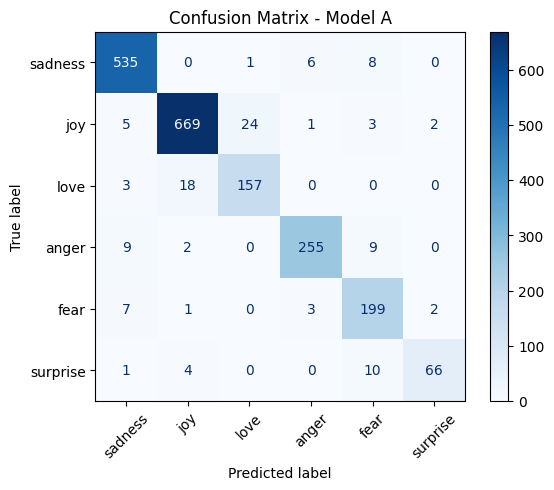

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    true_labels_a,
    predicted_labels_a,
    display_labels=label_names,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model A")
plt.show()

## MODEL B - FROZEN DISTILBERT

In [ ]:
from transformers import AutoModelForSequenceClassification

model_b = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
for param in model_b.distilbert.parameters():
    param.requires_grad = False

In [ ]:
for name, param in model_b.named_parameters():
    if param.requires_grad:
        print(name)

pre_classifier.weight
pre_classifier.bias
classifier.weight
classifier.bias


In [ ]:
from transformers import TrainingArguments

training_args_b = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_project/model_b_results",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer_b = Trainer(
    model=model_b,
    args=training_args_b,
    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_b.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,1.490319,1.469855,0.491000,0.198977
2,1.428051,1.413341,0.503500,0.205409
3,1.393043,1.398048,0.504500,0.205851


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3000, training_loss=1.4613795623779298, metrics={'train_runtime': 179.0569, 'train_samples_per_second': 268.071, 'train_steps_per_second': 16.754, 'total_flos': 1192291633152000.0, 'train_loss': 1.4613795623779298, 'epoch': 3.0})

In [ ]:
validation_results_b = trainer_b.evaluate()
print(validation_results_b)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
1.393043,1.398048,3,0.504500,0.205851


{'eval_loss': 1.398047685623169, 'eval_accuracy': 0.5045, 'eval_macro_f1': 0.20585133172450476}


In [ ]:
predictions_b = trainer_b.predict(tokenized_dataset["validation"])

predicted_labels_b = np.argmax(predictions_b.predictions, axis=1)
true_labels_b = predictions_b.label_ids

print(
    classification_report(
        true_labels_b,
        predicted_labels_b,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     sadness     0.4314    0.7891    0.5578       550
         joy     0.5785    0.8168    0.6773       704
        love     0.0000    0.0000    0.0000       178
       anger     0.0000    0.0000    0.0000       275
        fear     0.0000    0.0000    0.0000       212
    surprise     0.0000    0.0000    0.0000        81

    accuracy                         0.5045      2000
   macro avg     0.1683    0.2676    0.2059      2000
weighted avg     0.3223    0.5045    0.3918      2000



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


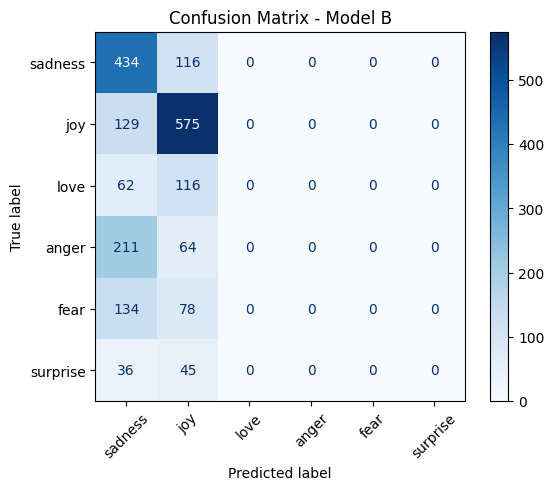

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    true_labels_b,
    predicted_labels_b,
    display_labels=label_names,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model B")
plt.show()

## MODEL C - DATA AUGMENTATION

In [ ]:
import random

random.seed(42)

def add_typo(text):
    words = text.split()
    candidates = [i for i, w in enumerate(words) if len(w) >= 4]

    if not candidates:
        return text

    word_idx = random.choice(candidates)
    word = words[word_idx]

    char_idx = random.randint(1, len(word) - 2)

    words[word_idx] = word[:char_idx] + word[char_idx + 1:]

    return " ".join(words)


def add_repetition(text):
    words = text.split()
    candidates = [i for i, w in enumerate(words) if len(w) >= 3]

    if not candidates:
        return text

    word_idx = random.choice(candidates)
    word = words[word_idx]

    char_idx = random.randint(1, len(word) - 2)
    char = word[char_idx]

    words[word_idx] = (
        word[:char_idx] +
        char * 3 +
        word[char_idx + 1:]
    )

    return " ".join(words)

In [ ]:
example_text = dataset["train"][0]["text"]

print("Original:", example_text)
print("Typo:", add_typo(example_text))
print("Repetition:", add_repetition(example_text))

Original: i didnt feel humiliated
Typo: i didnt feel huiliated
Repetition: i didnnnt feel humiliated


In [ ]:
from datasets import Dataset, concatenate_datasets

train_df_original = dataset["train"].to_pandas()

typo_df = train_df_original.sample(
    frac=0.25,
    random_state=42
).copy()

repetition_df = train_df_original.sample(
    frac=0.25,
    random_state=43
).copy()

typo_df["text"] = typo_df["text"].apply(add_typo)
repetition_df["text"] = repetition_df["text"].apply(add_repetition)

typo_dataset = Dataset.from_pandas(
    typo_df,
    preserve_index=False
)

repetition_dataset = Dataset.from_pandas(
    repetition_df,
    preserve_index=False
)

# Uskladi tip label stupca s originalnim datasetom
label_feature = dataset["train"].features["label"]

typo_dataset = typo_dataset.cast_column("label", label_feature)
repetition_dataset = repetition_dataset.cast_column("label", label_feature)

augmented_train = concatenate_datasets([
    dataset["train"],
    typo_dataset,
    repetition_dataset
])

print(augmented_train)

Casting the dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/4000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 24000
})


In [ ]:
print("Original train:", len(dataset["train"]))
print("Augmented train:", len(augmented_train))

print("\nPrimjeri typo augmentacije:")
for i in range(5):
    print(typo_df.iloc[i]["text"])

print("\nPrimjeri repetition augmentacije:")
for i in range(5):
    print(repetition_df.iloc[i]["text"])

Original train: 16000
Augmented train: 24000

Primjeri typo augmentacije:
ive made it through a week i just fel beaten down
i feel this strategy is wortwhile
i feel so worthless and weak what does he have to say that s what i want to fid out
i feel cever nov
im moved in ive ben feeling kind of gloomy

Primjeri repetition augmentacije:
im feeling a little regretful but itll paaass because thats what happens with regret
earrrth crake
i feel like i m on thhhe receiving end of a violent attack
i love tall guys they make me feel so little and innocent however innocent was thhhe last thing that i was that night
i couuuld feel was peace which was welcomed after a week of packing saying good bye and dealing with an overwhelming feeling of displacement


In [ ]:
tokenized_augmented_train = augmented_train.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/24000 [00:00<?, ? examples/s]

In [ ]:
validation_c = tokenized_dataset["validation"]

In [ ]:
from transformers import AutoModelForSequenceClassification

model_c = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
from transformers import TrainingArguments

training_args_c = TrainingArguments(
    output_dir="/content/drive/MyDrive/emotion_project/model_c_results",

    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,

    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,

    logging_steps=100,
    report_to="none"
)

In [ ]:
from transformers import Trainer

trainer_c = Trainer(
    model=model_c,
    args=training_args_c,
    train_dataset=tokenized_augmented_train,
    eval_dataset=validation_c,
    processing_class=tokenizer,
    compute_metrics=compute_metrics
)

In [ ]:
trainer_c.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.209962,0.177574,0.933000,0.906092
2,0.156370,0.152845,0.942000,0.914844
3,0.086123,0.166519,0.942500,0.918280


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=4500, training_loss=0.24139543893602158, metrics={'train_runtime': 650.8764, 'train_samples_per_second': 110.62, 'train_steps_per_second': 6.914, 'total_flos': 1788437449728000.0, 'train_loss': 0.24139543893602158, 'epoch': 3.0})

In [ ]:
validation_results_c = trainer_c.evaluate()
print(validation_results_c)

Training Loss,Validation Loss,Epoch,Accuracy,Macro F1
0.086123,0.166519,3,0.942500,0.918280


{'eval_loss': 0.16651880741119385, 'eval_accuracy': 0.9425, 'eval_macro_f1': 0.9182802554575037}


In [ ]:
predictions_c = trainer_c.predict(tokenized_dataset["validation"])

predicted_labels_c = np.argmax(predictions_c.predictions, axis=1)
true_labels_c = predictions_c.label_ids

print(
    classification_report(
        true_labels_c,
        predicted_labels_c,
        target_names=label_names,
        digits=4
    )
)

              precision    recall  f1-score   support

     sadness     0.9604    0.9691    0.9647       550
         joy     0.9738    0.9503    0.9619       704
        love     0.8663    0.9101    0.8877       178
       anger     0.9556    0.9382    0.9468       275
        fear     0.8784    0.9198    0.8986       212
    surprise     0.8608    0.8395    0.8500        81

    accuracy                         0.9425      2000
   macro avg     0.9159    0.9212    0.9183      2000
weighted avg     0.9433    0.9425    0.9427      2000



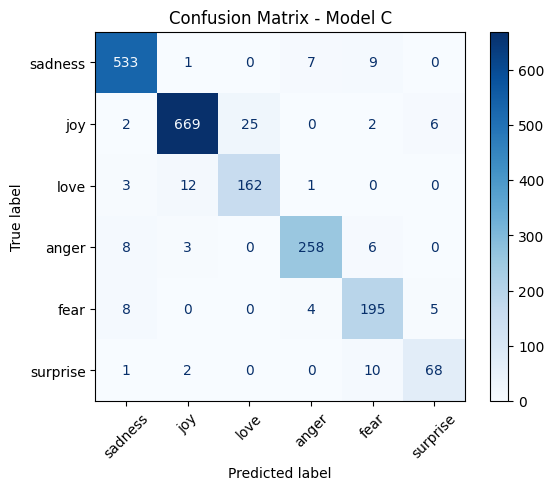

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    true_labels_c,
    predicted_labels_c,
    display_labels=label_names,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Confusion Matrix - Model C")
plt.show()

## ANALIZA ROBUSNOSTI MODELA


In [ ]:
test_df = dataset["test"].to_pandas()

print("Broj test primjera:", len(test_df))
test_df.head()

Broj test primjera: 2000


,text,label
0,im feeling rather rotten so im not very ambiti...,0
1,im updating my blog because i feel shitty,0
2,i never make her separate from me because i do...,0
3,i left with my bouquet of red and yellow tulip...,1
4,i was feeling a little vain when i did this one,0


In [ ]:
def add_punctuation(text):
    punctuation_options = ["!", "!!", "?", "..."]
    return text + random.choice(punctuation_options)

In [ ]:
random.seed(42)

typo_test_df = test_df.copy()
typo_test_df["text"] = typo_test_df["text"].apply(add_typo)

random.seed(42)

repetition_test_df = test_df.copy()
repetition_test_df["text"] = repetition_test_df["text"].apply(add_repetition)

random.seed(42)

punctuation_test_df = test_df.copy()
punctuation_test_df["text"] = punctuation_test_df["text"].apply(add_punctuation)

In [ ]:
for i in range(5):
    print("ORIGINAL:   ", test_df.iloc[i]["text"])
    print("TYPO:       ", typo_test_df.iloc[i]["text"])
    print("REPETITION: ", repetition_test_df.iloc[i]["text"])
    print("PUNCTUATION:", punctuation_test_df.iloc[i]["text"])
    print()

In [ ]:
from datasets import Dataset

typo_test = Dataset.from_pandas(
    typo_test_df,
    preserve_index=False
)

repetition_test = Dataset.from_pandas(
    repetition_test_df,
    preserve_index=False
)

punctuation_test = Dataset.from_pandas(
    punctuation_test_df,
    preserve_index=False
)

In [ ]:
label_feature = dataset["test"].features["label"]

typo_test = typo_test.cast_column("label", label_feature)
repetition_test = repetition_test.cast_column("label", label_feature)
punctuation_test = punctuation_test.cast_column("label", label_feature)

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized_typo_test = typo_test.map(
    tokenize_function,
    batched=True
)

tokenized_repetition_test = repetition_test.map(
    tokenize_function,
    batched=True
)

tokenized_punctuation_test = punctuation_test.map(
    tokenize_function,
    batched=True
)

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized_dataset["test"]

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})

In [ ]:
def evaluate_model(trainer, test_dataset, model_name, test_name):
    predictions = trainer.predict(test_dataset)

    predicted_labels = np.argmax(predictions.predictions, axis=1)
    true_labels = predictions.label_ids

    accuracy = accuracy_score(true_labels, predicted_labels)
    macro_f1 = f1_score(true_labels, predicted_labels, average="macro")

    return {
        "Model": model_name,
        "Test": test_name,
        "Accuracy": accuracy,
        "Macro F1": macro_f1
    }

In [ ]:
test_sets = {
    "Original": tokenized_dataset["test"],
    "Typo": tokenized_typo_test,
    "Repetition": tokenized_repetition_test,
    "Punctuation": tokenized_punctuation_test
}

In [ ]:
models = {
    "Model A": trainer_a,
    "Model B": trainer_b,
    "Model C": trainer_c
}

In [ ]:
results = []

for model_name, trainer in models.items():
    for test_name, test_data in test_sets.items():

        result = evaluate_model(
            trainer,
            test_data,
            model_name,
            test_name
        )

        results.append(result)

In [ ]:
import pandas as pd

results_df = pd.DataFrame(results)

results_df

,Model,Test,Accuracy,Macro F1
0,Model A,Original,0.9310,0.884520
1,Model A,Typo,0.8595,0.821796
2,Model A,Repetition,0.8840,0.840052
3,Model A,Punctuation,0.9240,0.876777
4,Model B,Original,0.4960,0.201093
5,Model B,Typo,0.4830,0.195276
6,Model B,Repetition,0.4925,0.198276
7,Model B,Punctuation,0.4895,0.197841
8,Model C,Original,0.9220,0.870842
9,Model C,Typo,0.8760,0.824660


In [ ]:
original_f1 = (
    results_df[results_df["Test"] == "Original"]
    .set_index("Model")["Macro F1"]
)

results_df["F1 Drop"] = results_df.apply(
    lambda row: original_f1[row["Model"]] - row["Macro F1"],
    axis=1
)

results_df

,Model,Test,Accuracy,Macro F1,F1 Drop
0,Model A,Original,0.9310,0.884520,0.000000
1,Model A,Typo,0.8595,0.821796,0.062724
2,Model A,Repetition,0.8840,0.840052,0.044469
3,Model A,Punctuation,0.9240,0.876777,0.007743
4,Model B,Original,0.4960,0.201093,0.000000
5,Model B,Typo,0.4830,0.195276,0.005817
6,Model B,Repetition,0.4925,0.198276,0.002817
7,Model B,Punctuation,0.4895,0.197841,0.003252
8,Model C,Original,0.9220,0.870842,0.000000
9,Model C,Typo,0.8760,0.824660,0.046182


In [ ]:
f1_table = results_df.pivot(
    index="Model",
    columns="Test",
    values="Macro F1"
)

f1_table

Test,Original,Punctuation,Repetition,Typo
Model,,,,
Model A,0.884520,0.876777,0.840052,0.821796
Model B,0.201093,0.197841,0.198276,0.195276
Model C,0.870842,0.873407,0.840460,0.824660


##USPOREDBA ROBUSNOSTI MODELA

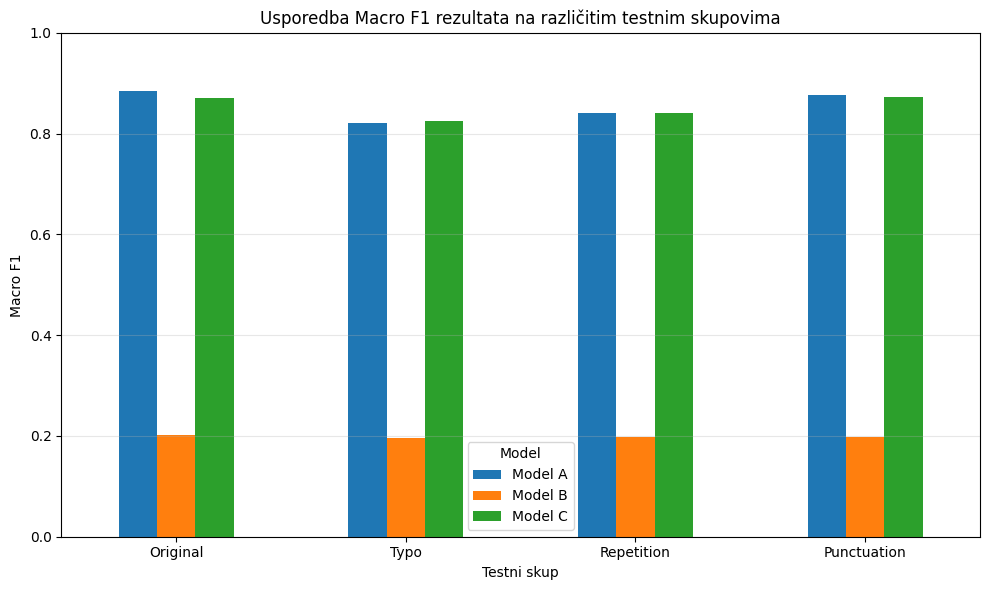

In [ ]:
import matplotlib.pyplot as plt

f1_plot = results_df.pivot(
    index="Test",
    columns="Model",
    values="Macro F1"
)

# Željeni redoslijed testova
f1_plot = f1_plot.loc[
    ["Original", "Typo", "Repetition", "Punctuation"]
]

ax = f1_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Usporedba Macro F1 rezultata na različitim testnim skupovima")
plt.xlabel("Testni skup")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

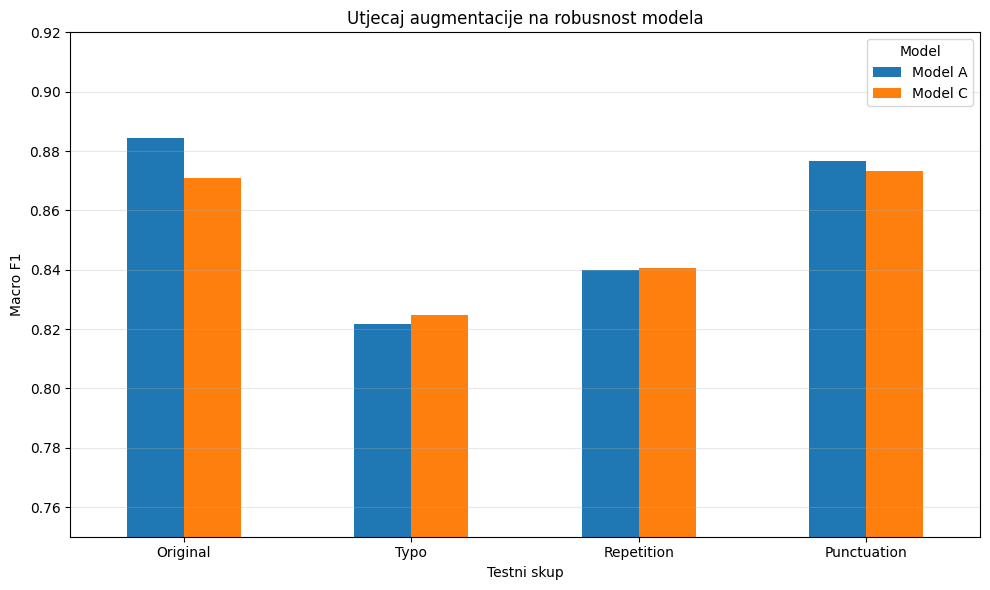

In [ ]:
ac_results = results_df[
    results_df["Model"].isin(["Model A", "Model C"])
]

ac_plot = ac_results.pivot(
    index="Test",
    columns="Model",
    values="Macro F1"
)

ac_plot = ac_plot.loc[
    ["Original", "Typo", "Repetition", "Punctuation"]
]

ax = ac_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Utjecaj augmentacije na robusnost modela")
plt.xlabel("Testni skup")
plt.ylabel("Macro F1")
plt.ylim(0.75, 0.92)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

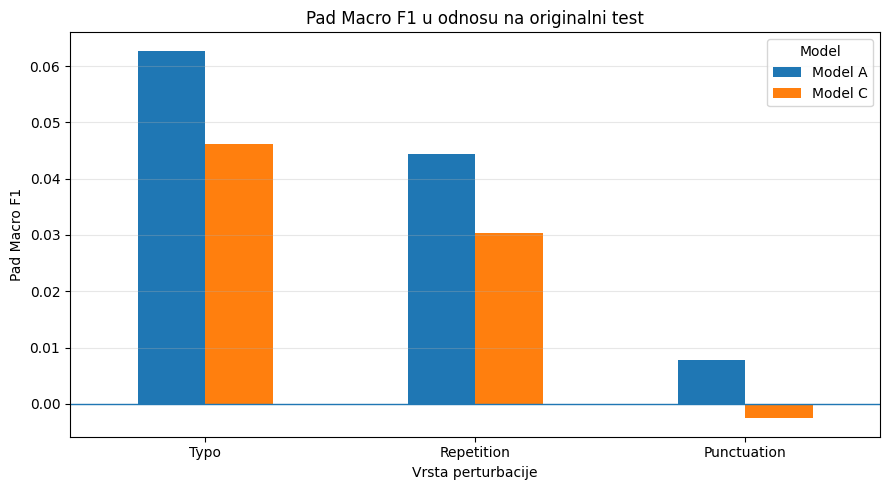

In [ ]:
drop_plot = results_df[
    (results_df["Model"].isin(["Model A", "Model C"])) &
    (results_df["Test"] != "Original")
].pivot(
    index="Test",
    columns="Model",
    values="F1 Drop"
)

drop_plot = drop_plot.loc[
    ["Typo", "Repetition", "Punctuation"]
]

ax = drop_plot.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Pad Macro F1 u odnosu na originalni test")
plt.xlabel("Vrsta perturbacije")
plt.ylabel("Pad Macro F1")
plt.axhline(0, linewidth=1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## ANALIZA POGREŠAKA

In [ ]:
pred_a_typo = trainer_a.predict(tokenized_typo_test)
pred_c_typo = trainer_c.predict(tokenized_typo_test)

labels_a_typo = np.argmax(pred_a_typo.predictions, axis=1)
labels_c_typo = np.argmax(pred_c_typo.predictions, axis=1)

true_labels_typo = pred_a_typo.label_ids

In [ ]:
interesting_examples = []

for i in range(len(true_labels_typo)):
    if (
        labels_a_typo[i] != true_labels_typo[i]
        and labels_c_typo[i] == true_labels_typo[i]
    ):
        interesting_examples.append(i)

print("Broj primjera gdje C ispravlja pogrešku A:", len(interesting_examples))

Broj primjera gdje C ispravlja pogrešku A: 96


In [ ]:
for i in interesting_examples:

    print("ORIGINAL:")
    print(test_df.iloc[i]["text"])

    print("TYPO:")
    print(typo_test_df.iloc[i]["text"])

    print("Točna emocija:",
          label_names[true_labels_typo[i]])

    print("Model A:",
          label_names[labels_a_typo[i]])

    print("Model C:",
          label_names[labels_c_typo[i]])

    print("-" * 70)

ORIGINAL:
i feel like i m defective or something for not having baby fever
TYPO:
i feel like i m deective or something for not having baby fever
Točna emocija: sadness
Model A: joy
Model C: sadness
----------------------------------------------------------------------
ORIGINAL:
i feel a little nervous i go to the gym
TYPO:
i feel a little nervos i go to the gym
Točna emocija: fear
Model A: joy
Model C: fear
----------------------------------------------------------------------
ORIGINAL:
i feel so embarrassed
TYPO:
i feel so embarrassd
Točna emocija: sadness
Model A: anger
Model C: sadness
----------------------------------------------------------------------
ORIGINAL:
i still feel stupid to be in that class this is all cause off pbss fault
TYPO:
i still fel stupid to be in that class this is all cause off pbss fault
Točna emocija: sadness
Model A: anger
Model C: sadness
----------------------------------------------------------------------
ORIGINAL:
i feel a bit stressed even though al

In [ ]:
pred_a_rep = trainer_a.predict(tokenized_repetition_test)
pred_c_rep = trainer_c.predict(tokenized_repetition_test)

labels_a_rep = np.argmax(pred_a_rep.predictions, axis=1)
labels_c_rep = np.argmax(pred_c_rep.predictions, axis=1)

true_labels_rep = pred_a_rep.label_ids

interesting_rep_examples = []

for i in range(len(true_labels_rep)):
    if (
        labels_a_rep[i] != true_labels_rep[i]
        and labels_c_rep[i] == true_labels_rep[i]
    ):
        interesting_rep_examples.append(i)

print(
    "Broj repetition primjera gdje C ispravlja pogrešku A:",
    len(interesting_rep_examples)
)

Broj repetition primjera gdje C ispravlja pogrešku A: 73


In [ ]:
for i in interesting_rep_examples:

    print("ORIGINAL:")
    print(test_df.iloc[i]["text"])

    print("REPETITION:")
    print(repetition_test_df.iloc[i]["text"])

    print("Točna emocija:",
          label_names[true_labels_rep[i]])

    print("Model A:",
          label_names[labels_a_rep[i]])

    print("Model C:",
          label_names[labels_c_rep[i]])

    print("-" * 70)

ORIGINAL:
i was feeling as heartbroken as im sure katniss was
REPETITION:
i was feeling as heaaartbroken as im sure katniss was
Točna emocija: sadness
Model A: joy
Model C: sadness
----------------------------------------------------------------------
ORIGINAL:
i feel a bit stressed even though all the things i have going on are fun
REPETITION:
i feel a bit stressed even though all the things i haaave going on are fun
Točna emocija: anger
Model A: sadness
Model C: anger
----------------------------------------------------------------------
ORIGINAL:
i feel like a naughty school girl because i am falling behind
REPETITION:
i feel like a nauggghty school girl because i am falling behind
Točna emocija: love
Model A: joy
Model C: love
----------------------------------------------------------------------
ORIGINAL:
i love neglecting this blog but sometimes i feel for my faithful readers
REPETITION:
i looove neglecting this blog but sometimes i feel for my faithful readers
Točna emocija: lov

##SUČELJE


In [ ]:
!pip install -q gradio

In [3]:
import torch
import torch.nn.functional as F

def predict_emotion(text):
    # Tokenizacija korisničkog teksta
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=MAX_LENGTH
    )

    # Prebacivanje ulaza na isti uređaj kao model
    device = next(model_c.parameters()).device
    inputs = {key: value.to(device) for key, value in inputs.items()}

    # Predikcija
    model_c.eval()

    with torch.no_grad():
        outputs = model_c(**inputs)

    # Logits -> vjerojatnosti
    probabilities = F.softmax(outputs.logits, dim=-1)[0]

    # Gradio očekuje rječnik: emocija -> vjerojatnost
    result = {
        label_names[i]: float(probabilities[i])
        for i in range(len(label_names))
    }

    return result

In [4]:
import gradio as gr

demo = gr.Interface(
    fn=predict_emotion,

    inputs=gr.Textbox(
        lines=3,
        placeholder="Enter a sentence, e.g. I feel really happy today!",
        label="Text"
    ),

    outputs=gr.Label(
        num_top_classes=6,
        label="Predicted emotion"
    ),

    title="Emotion Recognition with DistilBERT",

    description=(
        "Enter an English sentence and the model will predict "
        "one of six emotions: sadness, joy, love, anger, fear or surprise."
    ),

    examples=[
        ["I feel really happy today!"],
        ["I am terrified about tomorrow."],
        ["I feel so angry right now."],
        ["I really love spending time with you."],
        ["I feel completely hopeless."],
        ["I am so surprised this happened!"]
    ]
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ff6e5e38b9789df835.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


KeyboardInterrupt: 